In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import eigh
from opt_einsum import contract
from grid_lib.spherical_coordinates.analytical_radial_functions import Rnl_HO, Rn_STO, Rnl_LF
from grid_lib.pseudospectral_grids.gauss_legendre_lobatto import (
    GaussLegendreLobatto,
    Linear_map,
)
from grid_lib.pseudospectral_grids.femdvr import FEMDVR
from grid_lib.spherical_coordinates.angular_momentum import (
    LM_to_I,
    number_of_lm_states,
)

In [2]:
# Define the radial grid and the number of points per element
r_start = 0.0
r_max = 40.0
element_size = 2.0

nodes = np.arange(r_start, r_max + element_size, element_size)

n_points_pr_element = 11
n_points = (
    np.ones((len(nodes) - 1,), dtype=int) * n_points_pr_element
)  # Example number of points per element

GLL = FEMDVR(nodes, n_points, Linear_map, GaussLegendreLobatto)
r = GLL.r[1:-1]  # Exclude the endpoints
weights = GLL.weights[1:-1]  # Exclude the endpoints
D2 = GLL.D2[1:-1, 1:-1]  # Exclude the endpoints

In [3]:
#Define basis paramters and nuclear charge

Z = 1.0 # Nuclear charge for hydrogenic functions   
zeta_sto = 1.0 # Exponent for STO functions
l_max = 1
m_max = 1
n_max = 4
n_r = len(r)

nabla_sq = np.zeros((l_max+1, n_r, n_r))
for l in range(l_max+1):
    nabla_sq[l] = D2 - np.diag(l * (l + 1) / r**2)

In [4]:
#Setup the basis functions

basis = []

for n in range(1, n_max + 1):
    for m in range(-m_max, m_max+1):
        for l in range(abs(m), l_max + 1):
            phi_nlm = r*Rn_STO(r, n, zeta=zeta_sto)
            basis.append((l,m,phi_nlm))

n_bf = len(basis)

In [5]:
#Compute overlap, kinetic, and potential matrices

Spq = np.zeros((n_bf, n_bf))
Tpq = np.zeros((n_bf, n_bf))
Vpq = np.zeros((n_bf, n_bf))

for p in range(n_bf):
    lp, mp, phi_p = basis[p]
    for q in range(n_bf):
        lq, mq, phi_q = basis[q]
        if lp == lq and mp == mq:
            Spq[p, q] = contract("i,i->", weights, phi_p * phi_q)
            Tpq[p, q] = -0.5*contract("i, i, i ->", phi_p, nabla_sq[lq] @ phi_q, weights)
            Vpq[p, q] = -Z*contract("i,i->", weights, phi_p * phi_q / r)

# Form Hcore (Hpq)
Hpq = Tpq + Vpq
# Check that Hpq is symmetric
assert np.allclose(Hpq, Hpq.T), "Hamiltonian matrix is not symmetric"

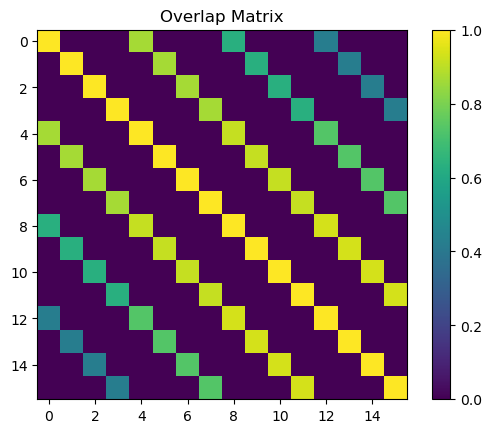

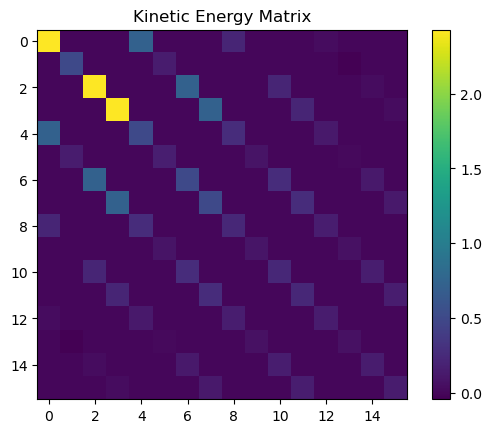

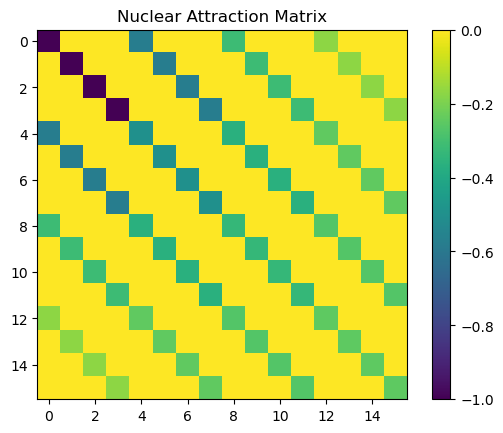

In [6]:
plt.figure()
plt.title("Overlap Matrix")
plt.imshow(Spq)
plt.colorbar()

plt.figure()
plt.title("Kinetic Energy Matrix")
plt.imshow(Tpq)
plt.colorbar()

plt.figure()
plt.title("Nuclear Attraction Matrix")
plt.imshow(Vpq)
plt.colorbar()

plt.show()

In [7]:
eps, C = eigh(Hpq, Spq)
print(f"Eigenvalues: {eps}")

Eigenvalues: [-0.5        -0.11931224 -0.11931224 -0.11931224 -0.11358979  0.10748027
  0.10748027  0.10748027  0.21401445  1.07406187  1.07406187  1.07406187
  2.39957535 15.48322465 15.48322465 15.48322465]
